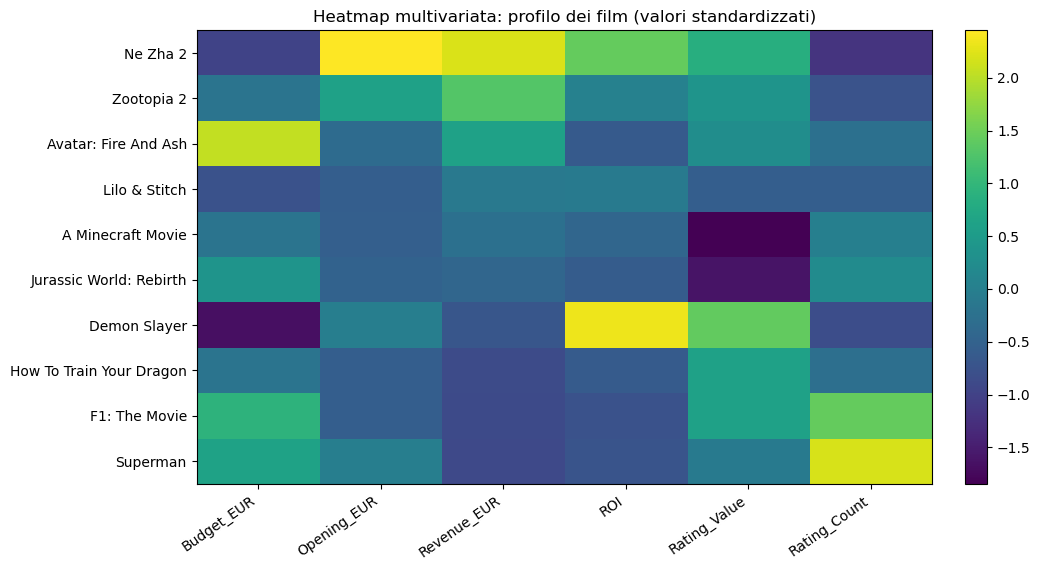

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

def leggi(nomi):
    for n in nomi:
        try:
            t = pd.read_csv(n)
            t.drop(columns=[c for c in t.columns if "Unnamed" in c], inplace=True, errors="ignore")
            t.columns = t.columns.str.strip()
            return t
        except:
            pass
    raise FileNotFoundError(str(nomi))

def norm_film(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

def parse_budget_eur(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ["", "-", "nan", "none"]:
        return np.nan
    m = re.search(r"(\d+(?:[.,]\d+)?)", s)
    if not m:
        return np.nan
    num = float(m.group(1).replace(",", "."))
    if "miliard" in s:
        return num * 1e9
    if "milion" in s:
        return num * 1e6
    return num

def parse_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.lower() in ["", "-", "nan", "none"]:
        return np.nan
    s = re.sub(r"[\$,€]", "", s)
    s = s.replace(" ", "").replace(",", "")
    s = re.sub(r"[^0-9\.]", "", s)
    if s == "":
        return np.nan
    return float(s)

def parse_rating(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower().replace("/10", "")
    try:
        return float(s)
    except:
        return np.nan

budget  = leggi(["Budget.csv"]).rename(columns={"Nome del film": "Movie"})
incassi = leggi(["IncassiTot.csv"]).rename(columns={"Nome del film": "Movie"})
rating  = leggi(["Rating.csv"]).rename(columns={"Nome del film": "Movie"})
opening = leggi(["opening.csv"]).rename(columns={"Nome film": "Movie"})

for t in [budget, incassi, rating, opening]:
    t["Movie"] = t["Movie"].apply(norm_film)

budget["Budget_EUR"] = budget["Budget (in euro)"].apply(parse_budget_eur)
incassi["Revenue_EUR"] = incassi["Incassi (in euro)"].apply(parse_money)
rating["Rating_Value"] = rating["Rating"].apply(parse_rating)
rating["Rating_Count"] = rating["numero rating"].apply(parse_money)

col_open = [c for c in opening.columns if c != "Movie"]
if len(col_open) == 0:
    raise ValueError("opening.csv non ha colonne oltre 'Movie'")
opening["Opening_EUR"] = opening[col_open[0]].apply(parse_money)

df = (
    budget[["Movie", "Budget_EUR"]]
    .merge(incassi[["Movie", "Revenue_EUR"]], on="Movie", how="inner")
    .merge(opening[["Movie", "Opening_EUR"]], on="Movie", how="left")
    .merge(rating[["Movie", "Rating_Value", "Rating_Count"]], on="Movie", how="left")
)

df = df.dropna(subset=["Budget_EUR", "Revenue_EUR"]).copy()
df["ROI"] = df["Revenue_EUR"] / df["Budget_EUR"]

df["Movie_label"] = df["Movie"].str.title()

variabili = ["Budget_EUR", "Opening_EUR", "Revenue_EUR", "ROI", "Rating_Value", "Rating_Count"]
X = df[variabili].copy()
for c in X.columns:
    X[c] = pd.to_numeric(X[c], errors="coerce")

Z = (X - X.mean()) / X.std(ddof=0)
Z = Z.fillna(0.0)

plt.figure(figsize=(10.5, 5.8))
im = plt.imshow(Z.to_numpy(), aspect="auto")
plt.yticks(range(len(df)), df["Movie_label"])
plt.xticks(range(len(variabili)), variabili, rotation=35, ha="right")
plt.title("Heatmap multivariata: profilo dei film (valori standardizzati)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
